In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [1]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "0"

import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
from pathlib import Path
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.cuda.amp import GradScaler, autocast
import torchvision.transforms as transforms
import torchvision.models as models
import torch.nn.functional as F

from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, classification_report, confusion_matrix
import seaborn as sns
from tqdm import tqdm

In [2]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
OUTPUT_DIR = '/kaggle/working'
NUM_CLASSES = 10
IMG_SIZE = 224
BATCH_SIZE = 64
NUM_WORKERS = 2

In [3]:
INPUT_DIR = '/kaggle/input/competitions/dlp-26t2-week9-assignment'

sizes = []
for class_folder in os.listdir(f'{INPUT_DIR}/train'):
    class_path = f'{INPUT_DIR}/train/{class_folder}'
    if not os.path.isdir(class_path): continue
    for img_name in os.listdir(class_path)[:50]:
        img = Image.open(f'{class_path}/{img_name}')
        sizes.append(img.size)  # (width, height)

print("=== TRAIN IMAGE SIZES ===")
size_counts = Counter(sizes)
for size, count in size_counts.most_common(10):
    print(f"  {size[0]}x{size[1]}: {count} images")
print(f"Total unique sizes: {len(size_counts)}")

# Check test images
test_sizes = []
test_path = f'{INPUT_DIR}/test'
for img_name in os.listdir(test_path)[:100]:
    img = Image.open(f'{test_path}/{img_name}')
    test_sizes.append(img.size)

print("\n=== TEST IMAGE SIZES ===")
test_size_counts = Counter(test_sizes)
for size, count in test_size_counts.most_common(10):
    print(f"  {size[0]}x{size[1]}: {count} images")
print(f"Total unique sizes: {len(test_size_counts)}")

# Check modes (RGB vs grayscale)
sample = Image.open(f'{INPUT_DIR}/test/{os.listdir(test_path)[0]}')
print(f"\nImage mode: {sample.mode}")
print(f"Channels: {len(sample.getbands())}")

=== TRAIN IMAGE SIZES ===
  800x600: 148 images
  600x800: 96 images
  800x533: 41 images
  800x800: 14 images
  800x534: 11 images
  800x450: 9 images
  450x800: 7 images
  800x601: 4 images
  800x530: 4 images
  597x800: 4 images
Total unique sizes: 139

=== TEST IMAGE SIZES ===
  800x600: 39 images
  600x800: 15 images
  800x533: 8 images
  800x450: 5 images
  800x800: 5 images
  800x534: 2 images
  731x800: 1 images
  800x384: 1 images
  739x800: 1 images
  800x653: 1 images
Total unique sizes: 32

Image mode: RGB
Channels: 3


In [6]:
INPUT_DIR = '/kaggle/input/competitions/dlp-26t2-week9-assignment'

train_dir = Path(INPUT_DIR) / 'train'
test_dir = Path(INPUT_DIR) / 'test'

CLASS_MAP = {
    'Amphibia': 0,
    'Animalia': 1,
    'Arachnida': 2,
    'Aves': 3,
    'Fungi': 4,
    'Insecta': 5,
    'Mammalia': 6,
    'Mollusca': 7,
    'Plantae': 8,
    'Reptilia': 9
}

IDX_TO_CLASS = {v: k for k, v in CLASS_MAP.items()}

class_counts = {}
all_train_files = []
all_train_labels = []

VALID_EXTENSIONS = ('.jpg', '.jpeg', '.png')

In [7]:
for class_name in sorted(os.listdir(train_dir)):
    class_path = train_dir / class_name
    if not class_path.is_dir() or class_name not in CLASS_MAP:
        continue
    
    files = sorted([
        str(class_path / f)
        for f in os.listdir(class_path)
        if f.lower().endswith(VALID_EXTENSIONS)
    ])
    class_counts[class_name] = len(files)
    
    for file_path in files:
        all_train_files.append(file_path)
        all_train_labels.append(CLASS_MAP[class_name])

test_files = sorted([
    str(test_dir / f)
    for f in os.listdir(test_dir)
    if f.lower().endswith(VALID_EXTENSIONS)
])

In [8]:
print("=" * 60)
print("DATASET SUMMARY")
print("=" * 60)
print(f"Total training images: {len(all_train_files)}")
print(f"Total test images: {len(test_files)}")
print("-" * 60)
print("Per-class distribution (Train):")
for class_name, count in sorted(class_counts.items(), key=lambda x: CLASS_MAP[x[0]]):
    idx = CLASS_MAP[class_name]
    print(f"  [{idx:02d}] {class_name:<12}: {count:>6} images")
print("=" * 60)

DATASET SUMMARY
Total training images: 9999
Total test images: 2000
------------------------------------------------------------
Per-class distribution (Train):
  [00] Amphibia    :   1000 images
  [01] Animalia    :   1000 images
  [02] Arachnida   :   1000 images
  [03] Aves        :   1000 images
  [04] Fungi       :    999 images
  [05] Insecta     :   1000 images
  [06] Mammalia    :   1000 images
  [07] Mollusca    :   1000 images
  [08] Plantae     :   1000 images
  [09] Reptilia    :   1000 images


In [9]:
# data augmentation pipeline for training from scratch
train_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(0.5),
    transforms.RandomRotation(15),           
    transforms.ColorJitter(0.2, 0.2, 0.2, 0.0),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
    transforms.RandomErasing(p=0.1)
])

# Validation & testing transforms (deterministic preprocessing)
val_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

In [10]:
class FloraFaunaDataset(Dataset):
    """
    Custom Dataset for Flora and Fauna image classification.
    Supports both labeled (train/val) and unlabeled (test) datasets.
    """
    def __init__(self, file_paths, labels=None, transform=None):
        self.file_paths = file_paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.file_paths)

    def __getitem__(self, idx):
        # Open image and convert to RGB
        img = Image.open(self.file_paths[idx]).convert('RGB')
        
        # Apply transformation if specified
        if self.transform is not None:
            img = self.transform(img)
        
        # Return (img, label) if labels are provided, otherwise just img
        if self.labels is not None:
            return img, self.labels[idx]
        return img

train_files, val_files, train_labels, val_labels = train_test_split(
    all_train_files,
    all_train_labels,
    test_size=0.15,
    stratify=all_train_labels,
    random_state=SEED
)

In [11]:
train_dataset = FloraFaunaDataset(
    file_paths=train_files,
    labels=train_labels,
    transform=train_transform
)

val_dataset = FloraFaunaDataset(
    file_paths=val_files,
    labels=val_labels,
    transform=val_transform
)

test_dataset = FloraFaunaDataset(
    file_paths=test_files,
    labels=None,
    transform=val_transform
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    drop_last=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

print("=" * 60)
print("DATASET & DATALOADER SANITY CHECK")
print("=" * 60)
sample_imgs, sample_lbls = next(iter(train_loader))

print(f"Batch shape: {sample_imgs.shape} (Expected: [{BATCH_SIZE}, 3, {IMG_SIZE}, {IMG_SIZE}])")
print(f"Label shape: {sample_lbls.shape} (Expected: [{BATCH_SIZE}])")
print(f"Label range: min={sample_lbls.min().item()} to max={sample_lbls.max().item()} (Expected: 0 to 9)")
print(f"Dataset sizes: Train: {len(train_dataset)}, Val: {len(val_dataset)}, Test: {len(test_dataset)}")
print("=" * 60)

DATASET & DATALOADER SANITY CHECK
Batch shape: torch.Size([64, 3, 224, 224]) (Expected: [64, 3, 224, 224])
Label shape: torch.Size([64]) (Expected: [64])
Label range: min=0 to max=9 (Expected: 0 to 9)
Dataset sizes: Train: 8499, Val: 1500, Test: 2000


In [14]:
def build_resnet34():
    model = models.resnet34(weights=None, num_classes=NUM_CLASSES)
    model.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
    model.maxpool = nn.Identity()
    for m in model.modules():
        if isinstance(m, nn.Conv2d):
            nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
        elif isinstance(m, nn.BatchNorm2d):
            nn.init.constant_(m.weight, 1)
            nn.init.constant_(m.bias, 0)
    return model

model_clean = build_resnet34().to(DEVICE)
print(f"ResNet-34 params: {sum(p.numel() for p in model_34.parameters()) / 1e6:.2f}M")

ResNet-34 params: 21.28M


In [15]:
NUM_EPOCHS_CLEAN = 100
criterion_clean = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer_clean = optim.SGD(model_clean.parameters(), lr=0.05, momentum=0.9,
                            weight_decay=5e-4, nesterov=True)
scheduler_clean = optim.lr_scheduler.CosineAnnealingLR(optimizer_clean, T_max=NUM_EPOCHS_CLEAN, eta_min=1e-6)
scaler_clean = GradScaler()

best_f1_clean = 0.0
epochs_no_improve = 0

print(f"\nTraining ResNet-34 CLEAN | LR=0.05 | No CutMix | Max {NUM_EPOCHS_CLEAN} epochs")
print("=" * 70)

for epoch in range(NUM_EPOCHS_CLEAN):
    model_clean.train()
    running_loss = 0.0
    for images, labels in tqdm(train_loader, desc=f"Ep {epoch+1}/{NUM_EPOCHS_CLEAN}", leave=False):
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        optimizer_clean.zero_grad()
        with autocast():
            outputs = model_clean(images)
            loss = criterion_clean(outputs, labels)
        scaler_clean.scale(loss).backward()
        scaler_clean.step(optimizer_clean)
        scaler_clean.update()
        running_loss += loss.item()

    model_clean.eval()
    val_loss = 0.0
    all_preds, all_targets = [], []
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            with autocast():
                outputs = model_clean(images)
            all_preds.extend(outputs.argmax(dim=1).cpu().numpy())
            all_targets.extend(labels.cpu().numpy())

    val_f1 = f1_score(all_targets, all_preds, average='micro')
    lr_now = optimizer_clean.param_groups[0]['lr']
    print(f"Ep {epoch+1:3d} | Train: {running_loss/len(train_loader):.4f} | F1: {val_f1:.4f} | LR: {lr_now:.6f}", end="")

    if val_f1 > best_f1_clean:
        best_f1_clean = val_f1
        epochs_no_improve = 0
        torch.save(model_clean.state_dict(), f'{OUTPUT_DIR}/best_resnet34_clean.pth')
        print(" BEST!")
    else:
        epochs_no_improve += 1
        print()
        if epochs_no_improve >= 15:
            print(f"\nEarly stopping at epoch {epoch+1}")
            break

    scheduler_clean.step()

print(f"\nResNet-34 Clean Best Val F1: {best_f1_clean:.4f}")

/tmp/ipykernel_58/2198624645.py:6: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler_clean = GradScaler()



Training ResNet-34 CLEAN | LR=0.05 | No CutMix | Max 100 epochs


Ep 1/100:   0%|          | 0/132 [00:00<?, ?it/s]/tmp/ipykernel_58/2198624645.py:20: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_58/2198624645.py:34: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Ep   1 | Train: 2.6593 | F1: 0.1427 | LR: 0.050000 BEST!


Ep 2/100:   0%|          | 0/132 [00:00<?, ?it/s]/tmp/ipykernel_58/2198624645.py:20: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_58/2198624645.py:34: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


...

Ep  98 | Train: 0.7747 | F1: 0.5493 | LR: 0.000112


Ep 99/100:   0%|          | 0/132 [00:00<?, ?it/s]/tmp/ipykernel_58/2198624645.py:20: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_58/2198624645.py:34: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Ep  99 | Train: 0.7653 | F1: 0.5527 | LR: 0.000050


Ep 100/100:   0%|          | 0/132 [00:00<?, ?it/s]/tmp/ipykernel_58/2198624645.py:20: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_58/2198624645.py:34: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Ep 100 | Train: 0.7704 | F1: 0.5553 | LR: 0.000013 BEST!

ResNet-34 Clean Best Val F1: 0.5553


=== ResNet-34 + CutMix Per-Class Report ===
              precision    recall  f1-score   support

    Amphibia     0.5139    0.4933    0.5034       150
    Animalia     0.5000    0.5133    0.5066       150
   Arachnida     0.5621    0.5733    0.5677       150
        Aves     0.6481    0.7000    0.6731       150
       Fungi     0.5625    0.5400    0.5510       150
     Insecta     0.5465    0.6267    0.5839       150
    Mammalia     0.6400    0.5333    0.5818       150
    Mollusca     0.5349    0.4600    0.4946       150
     Plantae     0.6241    0.5867    0.6048       150
    Reptilia     0.4489    0.5267    0.4847       150

    accuracy                         0.5553      1500
   macro avg     0.5581    0.5553    0.5552      1500
weighted avg     0.5581    0.5553    0.5552      1500



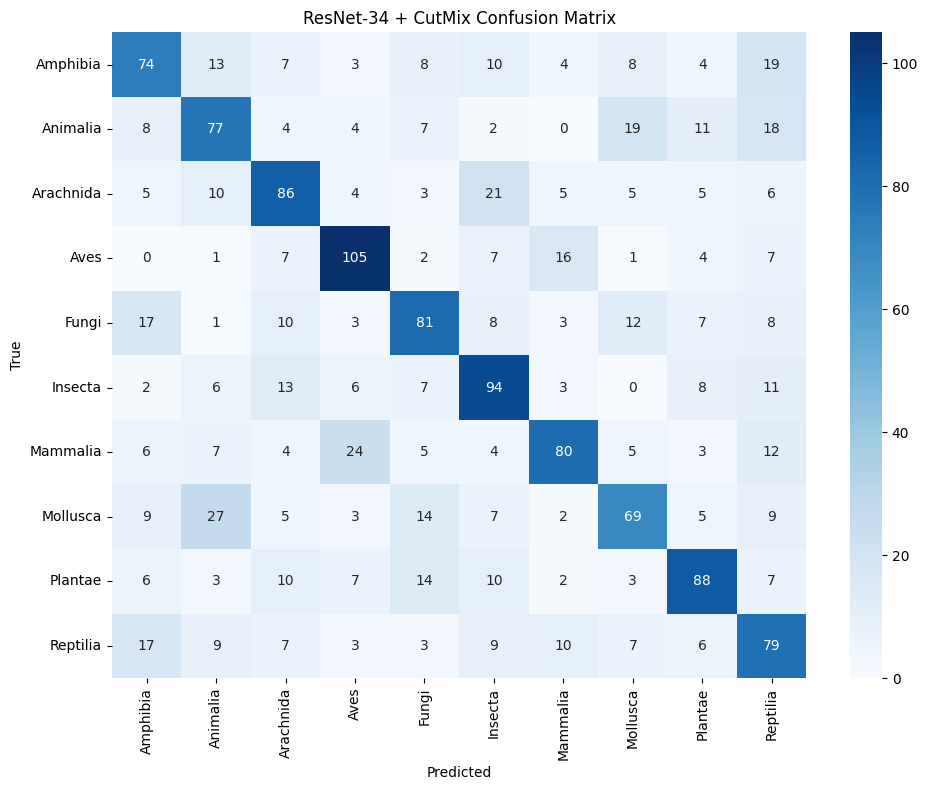

In [16]:
model_34.load_state_dict(torch.load(f'{OUTPUT_DIR}/best_resnet34_clean.pth'))
model_34.eval()
all_preds, all_targets = [], []

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(DEVICE)
        outputs = model_34(images)
        all_preds.extend(outputs.argmax(dim=1).cpu().numpy())
        all_targets.extend(labels.numpy())
        
print("=== ResNet-34 + CutMix Per-Class Report ===")
print(classification_report(all_targets, all_preds,
      target_names=[IDX_TO_CLASS[i] for i in range(NUM_CLASSES)], digits=4))

# Confusion Matrix
cm = confusion_matrix(all_targets, all_preds)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=[IDX_TO_CLASS[i] for i in range(NUM_CLASSES)],
            yticklabels=[IDX_TO_CLASS[i] for i in range(NUM_CLASSES)])
plt.title('ResNet-34 + CutMix Confusion Matrix')
plt.xlabel('Predicted'); plt.ylabel('True')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/confusion_matrix_resnet34_clean.png', dpi=120)
plt.show()

In [18]:
model_34.load_state_dict(torch.load(f'{OUTPUT_DIR}/best_resnet34_clean.pth'))
model_34.eval()

resnet34_preds = []

with torch.no_grad():
    for images in tqdm(test_loader, desc="ResNet-34 inference"):
        images = images.to(DEVICE)
        preds = model_34(images).argmax(dim=1).cpu().numpy()
        resnet34_preds.extend(preds)
        
test_image_ids = [os.path.splitext(os.path.basename(f))[0] for f in test_files]

submission = pd.DataFrame({'Image_ID': test_image_ids, 'Label': resnet34_preds})
submission = submission.sort_values('Image_ID').reset_index(drop=True)

submission.to_csv(f'{OUTPUT_DIR}/submission_resnet34_clean.csv', index=False)

print(f"Saved submission_resnet34_clean.csv ({len(submission)} rows)")
print(f"Best Val F1: {best_f1_clean:.4f}")

ResNet-34 inference: 100%|██████████| 32/32 [00:42<00:00,  1.34s/it]

Saved submission_resnet34_clean.csv (2000 rows)
Best Val F1: 0.5553
